<a href="https://colab.research.google.com/github/RojasG4mer/Fundamentos-de-Procesamiento-Digital-de-Imagenes/blob/main/Operaciones_a_nivel_pixel_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Operaciones a nivel píxel 01
En estos códigos se mostrarán algunas operaciones a nivel píxel, implementación de estos algoritmos, obtención del histograma de la imagen y un algoritmo sencillo para reconocer objetos apartir de los lóbulos del histograma de la imagen.

Montamos el drive para poder acceder a las imagenes.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# librerias para importar la imagen y mostrarla
import cv2
import matplotlib.pyplot as plt

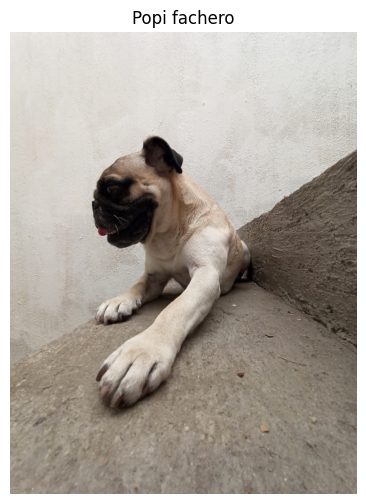

In [4]:

# 1. Definir la ruta del archivo (ajusta el nombre del archivo)
path = '/content/drive/MyDrive/Procesamiento Digital del Imágenes/Operaciones a nivel pixel/Popi_fachero.jpg'

# 2. Leer la imagen
# Nota: OpenCV lee las imágenes en formato BGR por defecto
popi_fachero = cv2.imread(path)

if popi_fachero is None:
    print("Error: No se pudo cargar la imagen. Verifica que la ruta sea correcta.")
else:
    # 3. Convertir de BGR a RGB para mostrarla correctamente con Matplotlib
    popi_fachero_rgb = cv2.cvtColor(popi_fachero, cv2.COLOR_BGR2RGB)

    # 4. Mostrar la imagen
    plt.figure(figsize=(8, 6))
    plt.imshow(popi_fachero_rgb)
    plt.title('Popi fachero')
    plt.axis('off')
    plt.show()

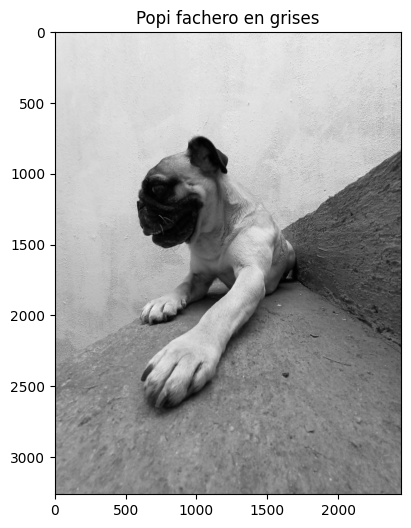

In [5]:

#convertimos la imagen a blanco y negro
popi_fachero_grises = cv2.cvtColor(popi_fachero_rgb, cv2.COLOR_BGR2GRAY)
# y la imprimimos para corroborar que se vea en esta tonalidad
plt.figure(figsize=(8, 6))
plt.imshow(popi_fachero_grises, cmap='gray')
plt.title('Popi fachero en grises')
# plt.axis('off')
plt.show()

## Histograma de la imagen

In [6]:
# Librerias:
import numpy as np

In [7]:
print(type(popi_fachero_grises)) # Vemos que es un array de numpy
print(popi_fachero_grises[0][1]) # se puede iterar como un array

<class 'numpy.ndarray'>
229


In [8]:
max, min = popi_fachero_grises.max(), popi_fachero_grises.min() # sacamos máximos y minimos de la imagen
# print(max, " " , min) 254  0

In [9]:
histograma = [0]*(max+1) # 254 + 1 ya que empieza en cero
# print(len(histograma))

In [10]:
for i in popi_fachero_grises: # recorremos cada fila
  for k in i: # recorremos cada columna
    histograma[k] = histograma[k] + 1 # Agregamos una cuenta al valor de la clase del histograma
print(histograma)

[658, 3039, 5599, 8105, 10274, 11551, 11575, 10810, 9998, 9293, 8753, 8872, 8433, 8409, 8160, 8108, 7601, 7273, 7002, 6779, 6724, 6451, 6424, 6177, 6264, 6059, 6209, 6391, 6544, 6831, 7121, 7072, 7310, 7616, 7705, 7901, 8053, 8198, 8255, 8477, 8710, 9163, 9569, 10039, 10641, 10752, 11292, 11465, 12078, 12675, 12920, 13235, 13511, 13713, 14236, 14395, 14882, 15421, 15578, 15956, 16081, 16434, 16943, 17520, 17668, 17944, 18750, 19462, 20073, 20494, 21030, 21686, 21737, 21947, 22420, 22171, 22026, 22283, 22125, 22413, 22400, 22250, 22397, 22136, 22332, 22697, 22535, 22642, 22550, 23082, 22855, 22548, 22155, 22131, 22046, 21964, 21828, 21988, 21824, 21864, 21887, 22140, 22260, 22802, 22883, 23289, 24204, 25387, 26560, 27382, 28440, 29580, 31441, 33503, 35703, 38313, 40909, 43330, 46204, 49566, 53066, 56563, 60403, 63121, 65981, 68132, 70755, 73550, 76610, 80271, 83689, 86661, 88768, 89817, 88881, 86024, 83167, 79570, 76164, 72491, 69416, 65125, 62683, 59862, 57514, 54581, 51142, 46210, 416

Text(0.5, 1.0, 'Histograma de la imagen Popi Fachero')

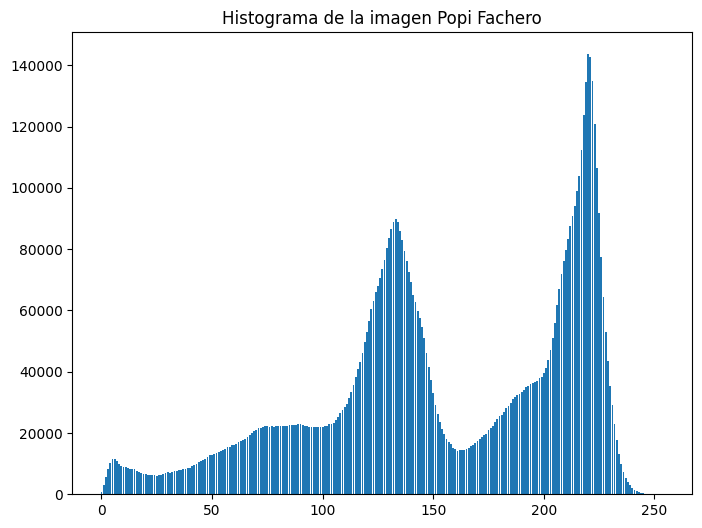

In [11]:
plt.figure(figsize=(8, 6))
# graficamos el histograma de frecuencias
plt.bar(range(len(histograma)), histograma)
plt.title('Histograma de la imagen Popi Fachero')

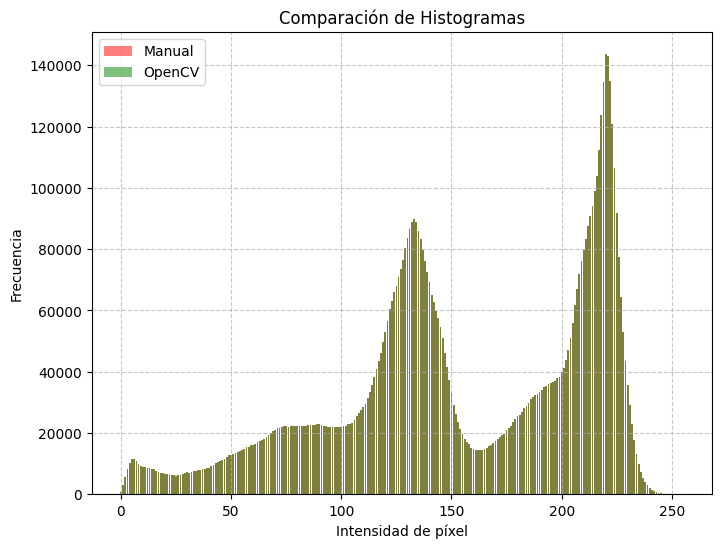

In [12]:
# Calcular el histograma con OpenCV
# cv2.calcHist(images, channels, mask, histSize, ranges)
hist_cv2 = cv2.calcHist([popi_fachero_grises], [0], None, [256], [0, 256])

# Corregimos el print: usamos 1 en lugar de 0 para la dimensión, o simplemente aplanamos
# print(hist_cv2.flatten())

# Graficar para comparar
plt.figure(figsize=(8, 6))
# histograma manual (rojo)
plt.bar(range(len(histograma)), histograma, color='r', alpha=0.5, label='Manual')
# histograma OpenCV (verde) - usamos .flatten() para convertir a 1D
plt.bar(range(256), hist_cv2.flatten(), color='g', alpha=0.5, label='OpenCV')

plt.title('Comparación de Histogramas')
plt.xlabel('Intensidad de píxel')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Operaciones a nivel pixel
Operaciones que se aplican sobre cada uno de los píxeles de la imagen.-

In [13]:
# Función graficar
def grafi_imag(imagen, titulo):
  plt.figure(figsize=(8, 6))
  plt.imshow(imagen, cmap='gray')
  plt.title(titulo)
  plt.axis('off')
  plt.show()

### Operador identidad
Crea una imagen igual a la imagen original:
$$ q = p $$

In [14]:
def opidentidad(p):
  q = p
  return q

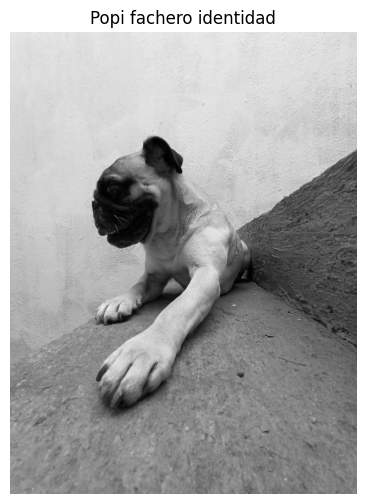

In [15]:
popi_fachero_identidad = []
fila = []
for j in popi_fachero_grises: # fila
  for i in j: # columna
    fila.append(opidentidad(i))
  popi_fachero_identidad.append(fila)
  fila = []
    # print(popi_fachero_identidad)
grafi_imag(popi_fachero_identidad, 'Popi fachero identidad')

### Operador identidad inverso o negativo

Crea una imagen de salida que es la inversa de la imagen de entrada (el menor valor lo vuelve mayor y el menor el mayor / reoordena los valores):
$$ q = 255 - p $$


In [16]:
def opidentidadinverso(p):
  q = 255 - p
  return q

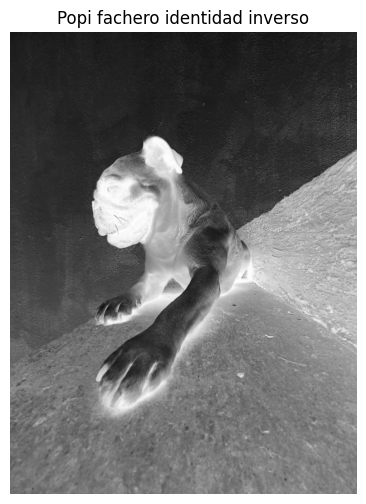

In [17]:
popi_fachero_identidad_inverso = []
fila = []
for j in popi_fachero_grises: # fila
  for i in j: # columna
    fila.append(opidentidadinverso(i))
  popi_fachero_identidad_inverso.append(fila)
  fila = []
    # print(popi_fachero_identidad)
grafi_imag(popi_fachero_identidad_inverso, 'Popi fachero identidad inverso')

### Operador umbral/thresholding
Se crea una imagen de salidad binaria a partir de una imagen de grises, donde le nivel de transición está dado por el parámetro de entrada $p_1$.
$$ q = \begin{cases}
    0 \text{ para } p\leq p_1\\
    255 \text{ para } p > p_1
\end{cases} $$

In [18]:
def opthresholding(p, p1):
  if p <= p1:
    q = 0
  else:
    q = 255
  return q

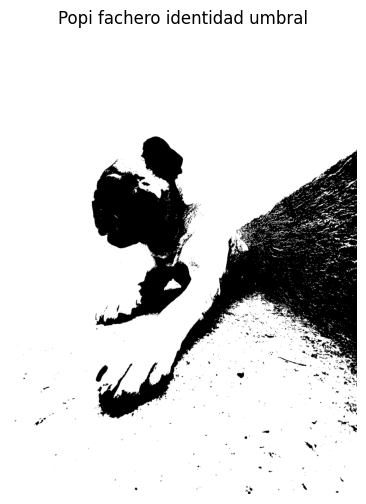

In [19]:
popi_fachero_identidad_umbral = []
fila = []
for j in popi_fachero_grises: # fila
  for i in j: # columna
    fila.append(opthresholding(i, 100))
  popi_fachero_identidad_umbral.append(fila)
  fila = []

grafi_imag(popi_fachero_identidad_umbral, 'Popi fachero identidad umbral')

### Operador umbral binario negativo
Crea una imagen de salida binaria a partir de una imagen de grises, donde todos los valores de gris cuyos niveles están en el intervalo definido por $p_1$ y $p_2$ son transformados a $0$, y todos los valores fuera de ese intervalo a $255$.
$$ q = \begin{cases}
    0 \text{ para } p\leq p_1 \text{ o } p\geq p_2\\
    255 \text{ o } p_1<p<p_2    
\end{cases}$$

In [20]:
def opthresholding_inverso(p, p1, p2):
  if p1 <= p <= p2:
    q = 255
  else:
    q = 0
  return q

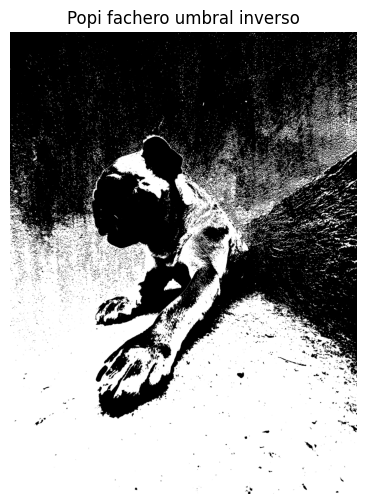

In [21]:
popi_fachero_umbral_inverso = []
fila = []
for j in popi_fachero_grises: # fila
  for i in j: # columna
    fila.append(opthresholding_inverso(i, 100, 200))
  popi_fachero_umbral_inverso.append(fila)
  fila = []

grafi_imag(popi_fachero_umbral_inverso, 'Popi fachero umbral inverso')

### Operador umbral escala de grises
Se crea una imagen de salida con los únicos valores de nivel de gris comprendidos en el intervalo definido por $p_1$ y $p_2$, y el resto a $255$-
$$ q = \begin{cases}
    255 \text{ para } p\leq p_1 \text{ o } p\geq p_2\\
    p \text{ para } p_1<p<p_2    
\end{cases}$$

In [22]:
def opthresholding_escalagrises(p, p1, p2):
  if p1 <= p <= p2:
    q = p
  else:
    q = 255
  return q

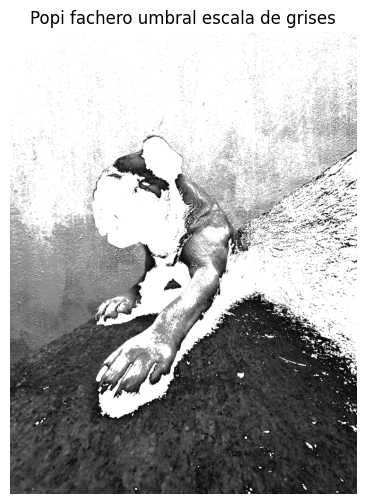

In [23]:
popi_fachero_umbral_grises = []
fila = []
for j in popi_fachero_grises: # fila
  for i in j: # columna
    fila.append(opthresholding_escalagrises(i, 100, 200))
  popi_fachero_umbral_grises.append(fila)
  fila = []

grafi_imag(popi_fachero_umbral_grises, 'Popi fachero umbral escala de grises')

### Operador umbral escala de grises inverso
Se crea una imagen de salida con los únicos valores de nivel de gris invertidos comprendidos en el intervalo definido por $p_1$ y $p_2$, y el resto a $255$
$$ q = \begin{cases}
    255 \text{ para } p\leq p_1 \text{ o } p\geq p_2\\
    255 - p \text{ o } p_1<p<p_2
\end{cases}$$

In [24]:
def opthresholding_escalagrises_inverso(p, p1, p2):
  if p1 <= p <= p2:
    q = 255 - p
  else:
    q = 255
  return q

<class 'list'>


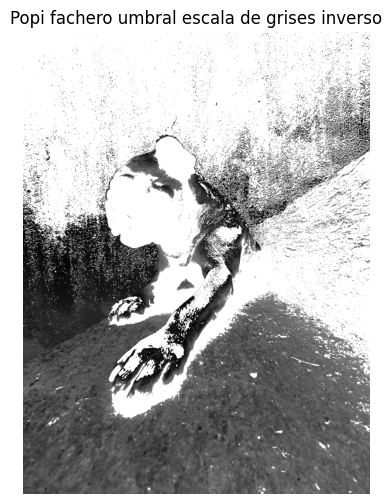

In [25]:
popi_fachero_umbral_grises_inverso = []
fila = []
for j in popi_fachero_grises: # fila
  for i in j: # columna
    fila.append(opthresholding_escalagrises_inverso(i, 100, 200))
  popi_fachero_umbral_grises_inverso.append(fila)
  fila = []
print(type(popi_fachero_umbral_grises_inverso))
grafi_imag(popi_fachero_umbral_grises_inverso, 'Popi fachero umbral escala de grises inverso')

### Operador de reducción de nivel de grises
Crea una imagen de salida con un menor número de niveles de gris respecto de la imagen original de entrada, la imagen de entrada es reducida a $n+1$ niveles de gris.

$$ q = \begin{cases}
    0 \text{ para } p\leq p_1\\
    q_1 \text{ para } p_1\leq p\leq p_2\\
    q_2 \text{ para } p_2\leq p\leq p_3\\
    \dots\\
    q_n \text{ o } p_{n-1}\leq p \leq 255    
\end{cases}$$

In [26]:
def opthresholding_red_escala_grises(p, p_escalas, q_valores):
  # Primero organizamos los valores de escalas y de q_valores
  p_escalas.sort()
  q_valores.sort()
  contador = 0
  for i in p_escalas: # tomamos el valor de la escala
    if p <= i: # comparamos si es menor y le damos el valor de esa escala
      return q_valores[contador] # regresamos solo el valor que si cumplió
    contador += 1
  # Si no entra en ningún rango previo, devolvemos el último valor
  return q_valores[-1]

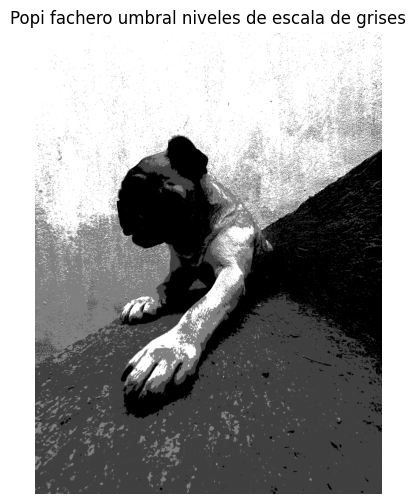

In [27]:
popi_fachero_umbral_redgrises = []
fila = []
p_escalas = [100, 150 ,200, 240]
q_valores = [50, 100 ,150, 250]

for j in popi_fachero_grises: # fila
  for i in j: # columna
    fila.append(opthresholding_red_escala_grises(i, p_escalas, q_valores))
  popi_fachero_umbral_redgrises.append(fila)
  fila = []

# Convertimos a array de numpy con un tipo de dato válido (uint8) para graficar
img_final = np.array(popi_fachero_umbral_redgrises, dtype=np.uint8)
grafi_imag(img_final, 'Popi fachero umbral niveles de escala de grises')

## Umbral por método Otsu


Umbral calculado por OpenCV (Otsu): 157.0
Umbral calculado manualmente: 157


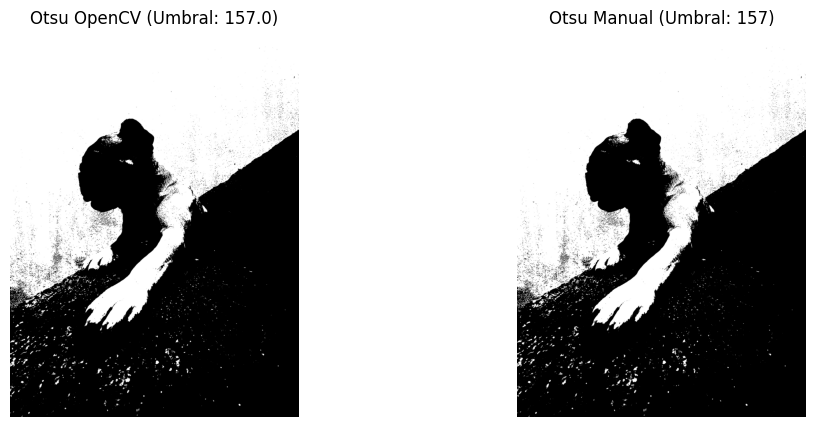

In [28]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Implementación usando OpenCV
# cv2.threshold con el flag cv2.THRESH_OTSU calcula automáticamente el umbral
umbral_otsu, img_otsu_cv2 = cv2.threshold(popi_fachero_grises, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f'Umbral calculado por OpenCV (Otsu): {umbral_otsu}')

# 2. Implementación Manual paso a paso
def manual_otsu(image):
    # Obtener el histograma y normalizarlo para obtener probabilidades
    hist = cv2.calcHist([image], [0], None, [256], [0, 256]).flatten()
    hist_norm = hist / hist.sum()

    # Sumas acumuladas y medias acumuladas
    cum_sum = np.cumsum(hist_norm)
    cum_mean = np.cumsum(hist_norm * np.arange(256))

    # Media global
    global_mean = cum_mean[-1]

    max_variance = 0
    threshold = 0

    # Iterar sobre todos los posibles umbrales
    for t in range(256):
        w0 = cum_sum[t] # Peso de la clase fondo
        w1 = 1.0 - w0   # Peso de la clase objeto

        if w0 > 0 and w1 > 0:
            mu0 = cum_mean[t] / w0
            mu1 = (global_mean - cum_mean[t]) / w1

            # Varianza entre-clases
            variance = w0 * w1 * ((mu0 - mu1) ** 2)

            if variance > max_variance:
                max_variance = variance
                threshold = t

    return threshold

umbral_manual = manual_otsu(popi_fachero_grises)
print(f'Umbral calculado manualmente: {umbral_manual}')

# Aplicar el umbral manual
img_otsu_manual = (popi_fachero_grises > umbral_manual).astype(np.uint8) * 255

# Visualización
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_otsu_cv2, cmap='gray')
plt.title(f'Otsu OpenCV (Umbral: {umbral_otsu})')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_otsu_manual, cmap='gray')
plt.title(f'Otsu Manual (Umbral: {umbral_manual})')
plt.axis('off')

plt.show()